<a href="https://colab.research.google.com/github/tsopronyuk/dfa-lexical-analyzer/blob/main/notebooks/01_keywords_dfa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ============================================================================
# LEXICAL ANALYZER AND DFA VISUALIZER (PYTHON + GRAPHVIZ)
# Tokens: Keywords (go, goon, open, online), Numbers (0-9+), Noise (-6)
# ============================================================================

from graphviz import Digraph
from IPython.display import display, Markdown, HTML

# ============================================================================
# 1. TRANSITION TABLE AND SETTINGS
# ============================================================================

# Character classes (columns):
# 0: digit (0-9), 1:'g', 2:'o', 3:'p', 4:'e', 5:'n', 6:'l', 7:'i', 8:OTHER (Noise)

M = [
    #  0   1   2   3   4   5   6   7   8
    [  1,  2,  5, -6, -6, -6, -6, -6, -6 ], # 0: Start
    [  1, -5, -5, -5, -5, -5, -5, -5, -5 ], # 1: Accumulate number [0-9]+
    [ -6, -6,  3, -6, -6, -6, -6, -6, -6 ], # 2: 'g'
    [ -1, -1,  4, -1, -1, -1, -1, -1, -1 ], # 3: 'go' (if next is not 'o', it's -1: go)
    [ -1, -1, -1, -1, -1, 10, -1, -1, -1 ], # 4: 'goo' (if 'n' -> 10, else -1: go)
    [ -6, -6, -6,  6, -6,  8, -6, -6, -6 ], # 5: 'o'
    [ -6, -6, -6, -6,  7, -6, -6, -6, -6 ], # 6: 'op'
    [ -6, -6, -6, -6, -6, 11, -6, -6, -6 ], # 7: 'ope'
    [ -6, -6, -6, -6, -6, -6,  9, -6, -6 ], # 8: 'on'
    [ -6, -6, -6, -6, -6, -6, -6, 12, -6 ], # 9: 'onl'
    [ -2, -2, -2, -2, -2, -2, -2, -2, -2 ], # 10: Final 'goon' (-2)
    [ -3, -3, -3, -3, -3, -3, -3, -3, -3 ], # 11: Final 'open' (-3)
    [ -6, -6, -6, -6, -6, 13, -6, -6, -6 ], # 12: 'onli'
    [ -6, -6, -6, -6, 14, -6, -6, -6, -6 ], # 13: 'onlin'
    [ -4, -4, -4, -4, -4, -4, -4, -4, -4 ]  # 14: Final 'online' (-4)
]

# Final states information
TOKEN_INFO = {
    -1: ("Keyword", "go", 2),
    -2: ("Keyword", "goon", 4),
    -3: ("Keyword", "open", 4),
    -4: ("Keyword", "online", 6),
    -5: ("Number", None, None), # Variable length (sliced via i)
    -6: ("Skip", "Noise", 1)    # Noise (skip 1 character)
}

def class_symb(c):
    if c.isdigit(): return 0
    if c == 'g': return 1
    if c == 'o': return 2
    if c == 'p': return 3
    if c == 'e': return 4
    if c == 'n': return 5
    if c == 'l': return 6
    if c == 'i': return 7
    return 8 # All other characters

In [8]:
# ============================================================================
# 2. LEXICAL ANALYZER DRIVER
# ============================================================================

def lexical_analyzer(text, verbose=False):
    tokens = []
    text_buffer = text + '\0' # End-of-stream marker

    start = 0
    i = 0
    state = 0

    if verbose:
        print(f"\n--- STEP-BY-STEP TEXT ANALYSIS: '{text}' ---")

    while start < len(text_buffer) - 1:
        c = text_buffer[i]
        cl = class_symb(c)
        next_state = M[state][cl]

        if next_state < 0:
            if next_state == -6:
                # 1. NOISE: Discard 1 character (start += 1)
                if verbose:
                    print(f"| [NOISE] Skipped character '{text_buffer[start]}' at pos={start}")
                start += 1
                i = start
                state = 0

            elif next_state == -5:
                # 2. NUMBER (VARIABLE LENGTH): Use 'i' for slicing
                val = text_buffer[start:i]
                tokens.append({"type": "Number", "value": val})
                if verbose:
                    print(f"| [FOUND NUMBER] '{val}' (slice text[{start}:{i}])")

                # Pointer 'i' stopped at a non-digit, start next token from here!
                start = i
                state = 0

            else:
                # 3. KEYWORDS (FIXED LENGTH): Backtrack using known length
                token_type, kw_val, kw_len = TOKEN_INFO[next_state]
                tokens.append({"type": f"{token_type} ({kw_val})", "value": kw_val})
                if verbose:
                    print(f"| [FOUND KEYWORD] '{kw_val}' (shifted start += {kw_len})")

                # Backtrack: Shift start exactly by keyword length
                start = start + kw_len
                i = start
                state = 0
        else:
            state = next_state
            i += 1

    return tokens

In [9]:
# ============================================================================
# 3. COMPACT DFA VISUALIZATION (GRAPHVIZ)
# ============================================================================

def visualize_dfa_compact():
    dot = Digraph('DFA_Lexer_Compact', format='svg')

    # Formatting settings (compact size, left to right)
    dot.attr(rankdir='LR', size='11,5', ratio='compress')
    dot.attr('node', fontname='Helvetica', fontsize='10', height='0.35', width='0.35')
    dot.attr('edge', fontname='Helvetica', fontsize='8')

    # 1. Start node
    dot.node('start_node', shape='point', width='0')
    dot.edge('start_node', '0')

    # 2. Internal states (0..14)
    for state in range(15):
        dot.node(str(state), shape='circle', style='filled', fillcolor='#f8f9fa')

    # 3. Final states (excluding -6, which is moved to the note)
    final_info = {
        -1: ("Keyword\n'go'", '#d5f5e3'),
        -2: ("Keyword\n'goon'", '#d4e6f1'),
        -3: ("Keyword\n'open'", '#fcf3cf'),
        -4: ("Keyword\n'online'", '#ebdef0'),
        -5: ("Number\n[0-9]+", '#fdebd0')
    }

    for neg, (label, color) in final_info.items():
        dot.node(str(neg), label=f"{neg}\n{label}", shape='doublecircle',
                 style='filled', fillcolor=color)

    class_names = {0:'0-9', 1:'g', 2:'o', 3:'p', 4:'e', 5:'n', 6:'l', 7:'i', 8:'other'}

    # 4. Grouping transitions and generating 'else' labels
    for state in range(15):
        counts = {}
        for cls in range(9):
            nxt = M[state][cls]
            if nxt != -6: # Ignore noise
                counts[nxt] = counts.get(nxt, 0) + 1

        # Find dominant target state for "else"
        default_target = None
        for nxt, cnt in counts.items():
            if cnt >= 4 and nxt < 0:
                default_target = nxt

        grouped_edges = {}
        for cls in range(9):
            nxt = M[state][cls]
            if nxt == -6:
                continue

            if nxt == default_target:
                grouped_edges[nxt] = "else"
            else:
                if nxt not in grouped_edges or grouped_edges[nxt] == "else":
                    grouped_edges[nxt] = []
                if isinstance(grouped_edges[nxt], list):
                    grouped_edges[nxt].append(class_names[cls])

        for target, labels in grouped_edges.items():
            lbl = "else" if labels == "else" else ", ".join(labels)
            is_final = target < 0

            dot.edge(
                str(state),
                str(target),
                label=f" {lbl} ",
                style='dashed' if is_final else 'solid',
                color='#777777' if is_final else '#111111'
            )

    return dot

In [10]:
# ============================================================================
# 4. MAIN DEMO BLOCK
# ============================================================================

print("🖼️ Generating compact DFA visualization...")
dot_compact = visualize_dfa_compact()
#display(HTML(f"<div style='background: white; padding: 15px; border-radius: 8px; text-align: center;'>{dot_compact.pipe().decode('utf-8')}</div>"))

# Test string: numbers, intersecting words, missing spaces, and noise
sample_text = "goon 12345 goox open99 online"
print(f"\n👉 Input text: \"{sample_text}\"")

# Run with detailed logging
tokens = lexical_analyzer(sample_text, verbose=True)

print("\n" + "=" * 55)
print(f"{'No.':>3} | {'Token Type':<20} | {'Value':<15}")
print("-" * 55)
for idx, t in enumerate(tokens):
    print(f"{idx+1:>3} | {t['type']:<20} | {t['value']:<15}")
print("=" * 55)

🖼️ Generating compact DFA visualization...

👉 Input text: "goon 12345 goox open99 online"

--- STEP-BY-STEP TEXT ANALYSIS: 'goon 12345 goox open99 online' ---
| [FOUND KEYWORD] 'goon' (shifted start += 4)
| [NOISE] Skipped character ' ' at pos=4
| [FOUND NUMBER] '12345' (slice text[5:10])
| [NOISE] Skipped character ' ' at pos=10
| [FOUND KEYWORD] 'go' (shifted start += 2)
| [NOISE] Skipped character 'o' at pos=13
| [NOISE] Skipped character 'x' at pos=14
| [NOISE] Skipped character ' ' at pos=15
| [FOUND KEYWORD] 'open' (shifted start += 4)
| [FOUND NUMBER] '99' (slice text[20:22])
| [NOISE] Skipped character ' ' at pos=22
| [FOUND KEYWORD] 'online' (shifted start += 6)

No. | Token Type           | Value          
-------------------------------------------------------
  1 | Keyword (goon)       | goon           
  2 | Number               | 12345          
  3 | Keyword (go)         | go             
  4 | Keyword (open)       | open           
  5 | Number               | 99       

 Generating compact DFA visualization...


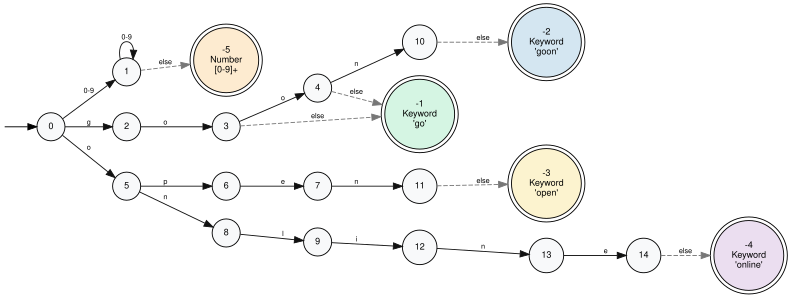


 Artifacts successfully saved to repository assets:
   - DOT Source : /content/assets/dot/example_1_paper.dot
   - SVG Image  : /content/assets/images/example_1_paper.svg
   - PDF Document: /content/assets/images/example_1_paper.pdf


In [11]:
import os
from pathlib import Path
from IPython.display import display

print(" Generating compact DFA visualization...")

# 1. Obtain the Graphviz object
# (Handles both returning the object from function or using global dot_compact)
dfa_example_1 = visualize_dfa_compact()
graph = dfa_example_1 if dfa_example_1 is not None else dot_compact

# 2. Automatically resolve repository root directory
current_dir = Path.cwd()
repo_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

# 3. Define asset output directories
dot_dir = repo_root / "assets" / "dot"
img_dir = repo_root / "assets" / "images"

# Ensure target directories exist
dot_dir.mkdir(parents=True, exist_ok=True)
img_dir.mkdir(parents=True, exist_ok=True)

filename_base = "example_1_paper"

# 4. Save raw Graphviz .dot source code
dot_path = dot_dir / f"{filename_base}.dot"
with open(dot_path, "w", encoding="utf-8") as f:
    f.write(graph.source)

# 5. Render SVG (for GitHub README / Web) and PDF (for LaTeX paper compilation)
base_output_path = str(img_dir / filename_base)

graph.format = "pdf"
graph.render(filename=base_output_path, cleanup=True)

graph.format = "svg"
graph.render(filename=base_output_path, cleanup=True)

# 6. Display the generated graph directly within Colab / Jupyter
display(graph)

# 7. Print execution summary
print("\n Artifacts successfully saved to repository assets:")
print(f"   - DOT Source : {dot_path.resolve()}")
print(f"   - SVG Image  : {(img_dir / f'{filename_base}.svg').resolve()}")
print(f"   - PDF Document: {(img_dir / f'{filename_base}.pdf').resolve()}")